In [1]:
import pandas as pd
import numpy as np
import glob
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras import layers

In [2]:
files = glob.glob("dataset/*.csv")  # если папка выше

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Количество файлов:", len(files))
print("Размер датасета:", df.shape)
df.head()

Количество файлов: 335
Размер датасета: (482183, 16)


,measured_on,ac_current__427,ac_power__423,ac_voltage__426,ambient_temp__428,das_battery_voltage__434,das_temp__433,dc_pos_current__425,dc_pos_voltage__424,dc_power__422,inverter_temp__432,module_temp_1__429,module_temp_2__430,module_temp_3__431,poa_irradiance__421,system_id
0,2022-01-01 00:00:00,1.6636,-1.2763,119.96,-10.397,13.857,-6.2139,-0.06849,-0.60298,0.03956,-7.7249,-8.9824,-8.7958,-9.1407,-0.02766,10
1,2022-01-01 00:01:00,1.6633,-1.3873,119.88,-10.409,13.856,-6.2227,-0.06904,0.35026,-0.02707,-7.7373,-8.9811,-8.8046,-9.1256,0.00000,10
2,2022-01-01 00:02:00,1.6633,-1.6314,119.94,-10.418,13.855,-6.2279,-0.06318,0.48327,-0.03209,-7.7441,-9.0176,-8.8019,-9.0924,0.00000,10
3,2022-01-01 00:03:00,1.6630,-1.5315,119.86,-10.429,13.856,-6.2419,-0.06647,-0.03104,0.00319,-7.7494,-9.0266,-8.8037,-9.1218,-0.02766,10
4,2022-01-01 00:04:00,1.6630,-1.1542,119.87,-10.439,13.856,-6.2472,-0.07142,1.01530,-0.06902,-7.7475,-8.9476,-8.8293,-9.1496,0.00000,10


In [3]:
df["measured_on"] = pd.to_datetime(df["measured_on"])
df = df.sort_values("measured_on")
df["month"] = df["measured_on"].dt.month
df["month"].value_counts()

month
3     44640
5     44640
8     44640
10    44640
12    44640
1     43200
4     43200
6     43200
7     43200
9     43200
11    42983
Name: count, dtype: int64

In [4]:
temp_cols = [col for col in df.columns if "module_temp" in col]

print("Найденные температурные колонки:", temp_cols)

df["module_temp"] = df[temp_cols].mean(axis=1)

Найденные температурные колонки: ['module_temp_1__429', 'module_temp_2__430', 'module_temp_3__431']


In [5]:
df = df.drop(columns=temp_cols)

In [6]:
df.columns = [col.split("__")[0] for col in df.columns]

print(df.columns.tolist())

['measured_on', 'ac_current', 'ac_power', 'ac_voltage', 'ambient_temp', 'das_battery_voltage', 'das_temp', 'dc_pos_current', 'dc_pos_voltage', 'dc_power', 'inverter_temp', 'poa_irradiance', 'system_id', 'month', 'module_temp']


In [7]:
# Оставляем только физически возможные данные
df = df[(df['poa_irradiance'] >= -5) & (df['poa_irradiance'] <= 1800)].copy()
df = df[df['ac_power'] >= -5]

In [8]:
df["hour"] = df["measured_on"].dt.hour
features = ['poa_irradiance', 'module_temp', 'ac_power', "ambient_temp", "hour"]



In [9]:
df = df.dropna()

In [10]:
import numpy as np

# 1. Находим все бесконечности в колонке efficiency и превращаем их в NaN
#df['efficiency'] = df['efficiency'].replace([np.inf, -np.inf], np.nan)

# 2. Удаляем строки, где теперь есть NaN (включая нашу бывшую бесконечность)
#df.dropna(subset=['efficiency'], inplace=True)
scaler = StandardScaler()
# Теперь запускаем обучение заново
X = df[features]
X_scaled = scaler.fit_transform(X)

In [10]:
# Посмотрим на реальный разброс значений в твоем мега-датасете
print(df['poa_irradiance'].describe())

# Проверим, есть ли там значения, которые физически невозможны (например, меньше -10)
print("Слишком маленькие значения:", (df['poa_irradiance'] < -10).sum())

count    377590.000000
mean        248.713552
std         377.088438
min          -5.000000
25%          -2.653200
50%           0.653230
75%         429.217500
max        1799.500000
Name: poa_irradiance, dtype: float64
Слишком маленькие значения: 0


def classify_advanced(row):
    irr = row["poa_irradiance"]
    power = row["ac_power"]
    eff = row["efficiency"]
    temp = row["module_temp"]

    # 0 — ночь
    if irr < 20:
        return 0

    # 1 — слабое солнце / облачность
    if irr < 200 and eff > 0.2:
        return 1

    # 2 — нормальная работа
    if irr >= 200 and eff > 0.6:
        return 2

    # 3 — перегрев (температура высокая → эффективность падает)
    if temp > 60 and eff < 0.5:
        return 3

    # 4 — аномалия (есть солнце, но мало мощности)
    if irr > 300 and eff < 0.3:
        return 4

    # 5 — прочие отклонения
    return 5

In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# 1. ПОДГОТОВКА ДАННЫХ
# Используем твои колонки: радиация, температура модуля и мощность
features = ['poa_irradiance', 'module_temp', 'ac_power']

# Фильтруем ночные данные (>10 Вт/м2) и берем выборку. 
# ВАЖНО: Иерархическая кластеризация требует много памяти, 
# поэтому для построения модели берем оптимальный сэмпл (5000-8000 точек).
df = df[df['poa_irradiance'] > 10][features].sample(5000, random_state=42)

# 2. МАСШТАБИРОВАНИЕ
# Это обязательно для корректной работы евклидова расстояния
scaler_hc = StandardScaler()
X_scaled = scaler_hc.fit_transform(df)

# 3. ИЕРАРХИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ
# n_clusters=4 — оптимально для СЭС: (Ясно, Облачно, Переменная облачность, Низкая инсоляция)
# linkage='ward' — минимизирует дисперсию внутри кластеров (самый точный метод)
hc_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['cluster'] = hc_model.fit_predict(X_scaled)

# Преобразуем метки в текст для красивой легенды
df['cluster_name'] = df['cluster'].apply(lambda x: f'Режим {x}')

# 4. ИНТЕРАКТИВНАЯ 3D ВИЗУАЛИЗАЦИЯ (PLOTLY)
fig = px.scatter_3d(
    df, 
    x='poa_irradiance', 
    y='module_temp', 
    z='ac_power',
    color='cluster_name',
    title='Интерактивная сегментация режимов СЭС (Agglomerative Clustering)',
    labels={
        'poa_irradiance': 'Радиация (Вт/м2)', 
        'module_temp': 'Температура (°C)', 
        'ac_power': 'Мощность (Вт)'
    },
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

# Настройка стиля точек
fig.update_traces(marker=dict(size=3, line=dict(width=0)))
fig.update_layout(
    scene=dict(
        xaxis_backgroundcolor="rgb(200, 200, 230)",
        yaxis_backgroundcolor="rgb(230, 200, 230)",
        zaxis_backgroundcolor="rgb(230, 230, 200)",
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

# Вывод графика (его можно крутить мышкой)
fig.show()

# 5. ПОДГОТОВКА ДЛЯ MLP
# Теперь у тебя есть размеченные данные, на которых можно учить нейросеть
print("Распределение точек по режимам:")
print(df['cluster_name'].value_counts())

Распределение точек по режимам:
cluster_name
Режим 0    1430
Режим 1    1262
Режим 2    1174
Режим 3    1037
Режим 4      97
Name: count, dtype: int64


In [12]:
fig = px.scatter_3d(
    df, 
    x='poa_irradiance', 
    y='ambient_temp', 
    z='ac_power',
    color='cluster_name',
    title='Интерактивная сегментация режимов СЭС (Agglomerative Clustering)',
    labels={
        'poa_irradiance': 'Радиация (Вт/м2)', 
        'ambient_temp': 'Температура (°C)', 
        'ac_power': 'Мощность (Вт)'
    },
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

# Настройка стиля точек
fig.update_traces(marker=dict(size=3, line=dict(width=0)))
fig.update_layout(
    scene=dict(
        xaxis_backgroundcolor="rgb(200, 200, 230)",
        yaxis_backgroundcolor="rgb(230, 200, 230)",
        zaxis_backgroundcolor="rgb(230, 230, 200)",
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

# Вывод графика (его можно крутить мышкой)
fig.show()

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['poa_irradiance', 'module_temp', 'ac_power', 'cluster', 'cluster_name'] but received: ambient_temp

Text(0.5, 0, 'Irradiance')

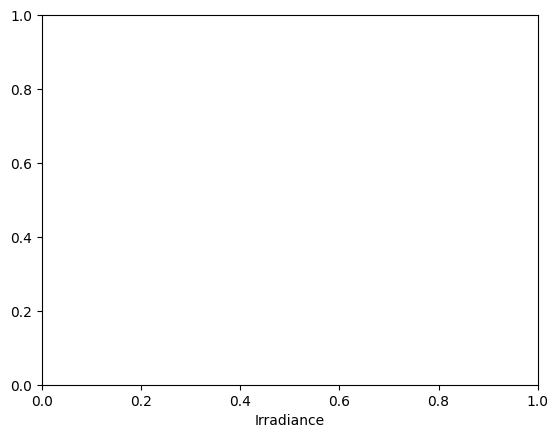

In [27]:
plt.xlabel('Irradiance')

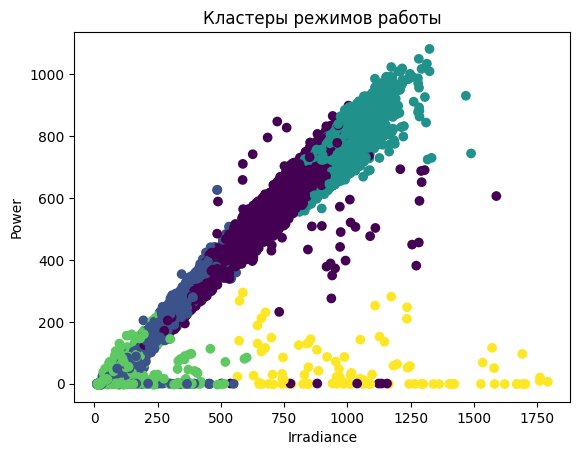

In [13]:
import matplotlib.pyplot as plt
plt.figure()

plt.scatter(
    df["poa_irradiance"],
    df["ac_power"],
    c=df["cluster"]
)

plt.xlabel("Irradiance")
plt.ylabel("Power")

plt.title("Кластеры режимов работы")
plt.show()

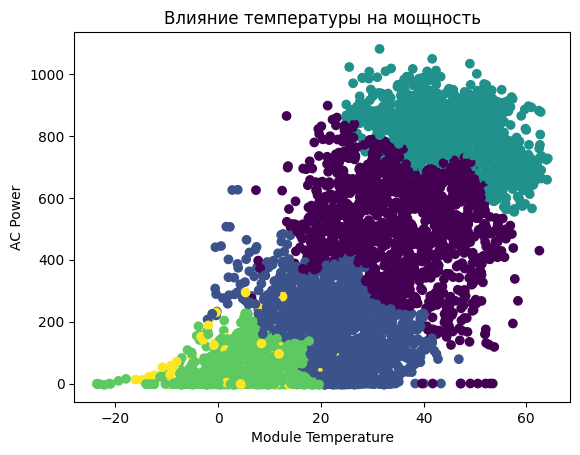

In [14]:
plt.figure()

plt.scatter(
    df["module_temp"],
    df["ac_power"],
    c=df["cluster"]
)

plt.xlabel("Module Temperature")
plt.ylabel("AC Power")
plt.title("Влияние температуры на мощность")

plt.show()

In [15]:
plt.figure()

plt.scatter(
    df["hour"],
    df["ac_power"],
    c=df["cluster"]
)

plt.xlabel("Hour")
plt.ylabel("AC Power")
plt.title("Зависимость мощности от времени суток")

plt.show()

KeyError: 'hour'

<Figure size 640x480 with 0 Axes>

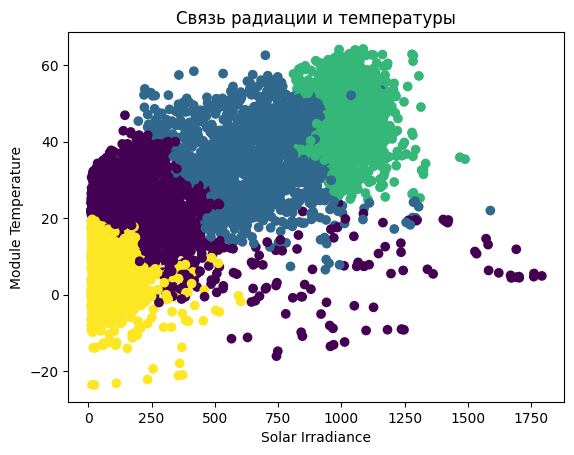

In [30]:
plt.figure()

plt.scatter(
    df["poa_irradiance"],
    df["module_temp"],
    c=df["cluster"]
)

plt.xlabel("Solar Irradiance")
plt.ylabel("Module Temperature")
plt.title("Связь радиации и температуры")

plt.show()

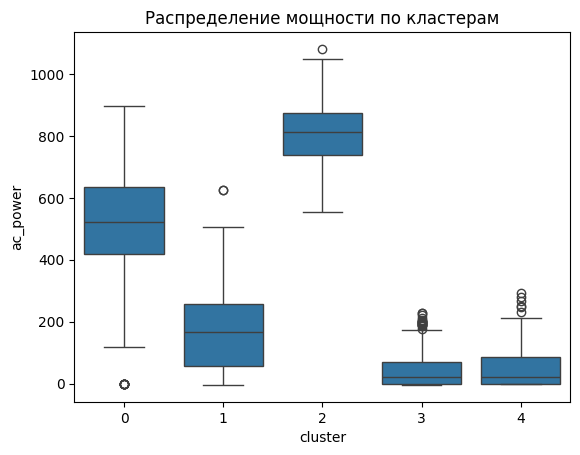

In [16]:
import seaborn as sns

sns.boxplot(x="cluster", y="ac_power", data=df)
plt.title("Распределение мощности по кластерам")
plt.show()

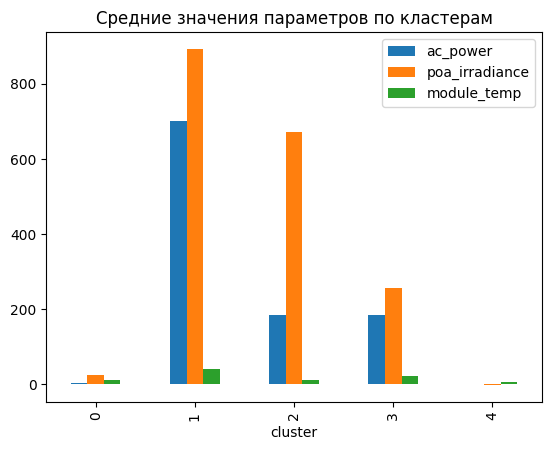

In [16]:
cluster_means = df.groupby("cluster").mean()

cluster_means[["ac_power", "poa_irradiance", "module_temp"]].plot(kind="bar")

plt.title("Средние значения параметров по кластерам")
plt.show()

In [34]:
plt.figure()

plt.scatter(
    df["poa_irradiance"],
    df["efficiency"],
    c=df["cluster"]
)

plt.xlabel("Solar Irradiance")
plt.ylabel("Efficiency")
plt.title("Связь радиации и эффективности")

plt.show()

KeyError: 'efficiency'

<Figure size 640x480 with 0 Axes>

In [19]:
cluster_analysis = df.groupby("cluster").mean()

print(cluster_analysis)

TypeError: dtype 'str' does not support operation 'mean'

 Интерпретация 
🟦 Cluster 1
irradiance ≈ 14
power ≈ 5
час ≈ 19

👉 это НОЧЬ

🟦 Cluster 0
irradiance ≈ 37
power ≈ 10
час ≈ 4

👉 раннее утро / поздний вечер

🟩 Cluster 2
irradiance ≈ 930
power ≈ 755
temp ≈ 35

👉 НОРМАЛЬНАЯ РАБОТА (идеальный режим)

🟨 Cluster 3
irradiance ≈ 349
power ≈ 269

👉 частичная генерация / облачность